# Setup

## Environment | Library Install

In [1]:
!pip install -q keras-tuner

## Library Needed

In [2]:
# Standard library
import hashlib
import os
import random
from collections import Counter, defaultdict

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image

# Machine learning
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers

# Scikit-learn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

2026-05-18 03:12:24.779294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779073944.980491      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779073945.038723      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779073945.500676      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779073945.500758      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779073945.500762      23 computation_placer.cc:177] computation placer alr

## Initialization

In [3]:
DATASET_PATH = "/kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset"
SEED = 42
IMAGE_SIZE = (224, 224)
IMAGE_SIZE_PAD = 224, 224
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

## Reproducibility

In [4]:
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## GPU Checking

In [5]:
print('Versi TensorFlow :', tf.__version__)
print('GPU terdeteksi   :', tf.config.list_physical_devices('GPU'))

Versi TensorFlow : 2.19.0
GPU terdeteksi   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load Dataset

In [6]:
dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels='inferred',
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=1,
    shuffle=False
)

Found 1946 files belonging to 4 classes.


I0000 00:00:1779073970.041370      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Exploratory Data Analysis

## EDA Setup

In [7]:
class_names = dataset.class_names
raw_file_paths = np.array(dataset.file_paths)

In [8]:
class_to_index = {name: i for i, name in enumerate(class_names)}
raw_labels = np.array([class_to_index[path.split("/")[-2]] for path in raw_file_paths])

In [9]:
label_map = {
    0: 'Earthquake',
    1: 'Land_Slide', 
    2: 'Urban_Fire',
    3: 'Water_Disaster'
}

## Classes

In [10]:
print("Classes:\n", class_names)
print('Total files:', len(raw_file_paths))

Classes:
 ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']
Total files: 1946


In [11]:
print(
    "Labels:"
    "\nEarthquake:", raw_labels[0], 
    "\nLand_Slide:", raw_labels[36], 
    "\nUrban_Fire:", raw_labels[492], 
    "\nWater_Disaster:", raw_labels[911]
)

Labels:
Earthquake: 0 
Land_Slide: 1 
Urban_Fire: 2 
Water_Disaster: 3


In [12]:
counter = Counter(raw_labels)
print("=== Distribusi Class ===")
for i, name in label_map.items():
    print(f"  {name}: {counter[i]}")
print(f"\nTotal: {sum(counter.values())}")

=== Distribusi Class ===
  Earthquake: 36
  Land_Slide: 456
  Urban_Fire: 419
  Water_Disaster: 1035

Total: 1946


## Handle Duplicated Data

In [13]:
for path, label in zip(raw_file_paths, raw_labels):
    try:
        img = tf.io.read_file(path)
        tf.image.decode_image(img)
    except Exception as e:
        print(f"File bermasalah: {path} | Label: {label}\n→ {e}")

File bermasalah: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0007.png | Label: 1
→ {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
File bermasalah: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0335.png | Label: 1
→ {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
File bermasalah: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0373.png | Label: 1
→ {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
File bermasalah: /kaggle/input/datasets/tungstor1/di

In [14]:
def filter_valid_paths(paths, labels):
    valid_paths, valid_labels = [], []
    removed = []

    for path, label in zip(paths, labels):
        try:
            img = tf.io.read_file(path)
            tf.image.decode_image(img)
            valid_paths.append(path)
            valid_labels.append(label)
        except Exception as e:
            removed.append((path, label, str(e)))
            print(f"❌ Removed: {path} | label: {label} → {e}")

    print(f"\n✅ Valid: {len(valid_paths)} | ❌ Removed: {len(removed)}")
    return valid_paths, valid_labels, removed

# Pakai di semua split
valid_paths, valid_labels, removed = filter_valid_paths(raw_file_paths, raw_labels)

❌ Removed: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0007.png | label: 1 → {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
❌ Removed: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0335.png | label: 1 → {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
❌ Removed: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0373.png | label: 1 → {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
❌ Removed: /kaggle/input/datasets/tungstor1/disaster-image-dataset/Dis

In [15]:
# hashes = {}
# same_class_duplicates = []
# diff_class_duplicates = []

# for path, label in zip(valid_paths, valid_labels):
#     with open(path, 'rb') as f:
#         h = hashlib.md5(f.read()).hexdigest()
    
#     if h in hashes:
#         orig_path, orig_label = hashes[h]
#         entry = {
#             'duplicate': path,
#             'duplicate_class': label_map[label],
#             'original': orig_path,
#             'original_class': label_map[orig_label]
#         }
#         if label_map[label] == label_map[orig_label]:
#             same_class_duplicates.append(entry)
#         else:
#             diff_class_duplicates.append(entry)
#     else:
#         hashes[h] = (path, label)

# # Ringkasan
# print(f"Total files        : {len(valid_paths)}")
# print(f"Unique files       : {len(hashes)}")
# print(f"Duplikat same class: {len(same_class_duplicates)}")
# print(f"Duplikat beda class: {len(diff_class_duplicates)}")

# # # Detail
# # if same_class_duplicates:
# #     print("\n=== SAME CLASS ===")
# #     for d in same_class_duplicates:
# #         print(f"  [{d['original_class']}]")
# #         print(f"  Original  : {d['original']}")
# #         print(f"  Duplicate : {d['duplicate']}")

# # if diff_class_duplicates:
# #     print("\n=== ⚠️ BEDA CLASS ===")
# #     for d in diff_class_duplicates:
# #         print(f"  [{d['original_class']} ↔ {d['duplicate_class']}]")
# #         print(f"  Original  : {d['original']}")
# #         print(f"  Duplicate : {d['duplicate']}")

# # Urutan prioritas: class dengan data paling sedikit duluan
# priority = ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']

# paths_to_remove = set()

# for d in diff_class_duplicates:
#     orig_priority  = priority.index(d['original_class'])
#     dupl_priority  = priority.index(d['duplicate_class'])
    
#     if orig_priority < dupl_priority:
#         # Original lebih prioritas → buang duplicate
#         paths_to_remove.add(d['duplicate'])
#     elif dupl_priority < orig_priority:
#         # Duplicate lebih prioritas → buang original
#         paths_to_remove.add(d['original'])
#     else:
#         # Prioritas sama (tidak mungkin terjadi di beda class, tapi jaga-jaga)
#         paths_to_remove.add(d['duplicate'])

# for d in same_class_duplicates:
#     paths_to_remove.add(d['duplicate'])

# print(f"Total dibuang: {len(paths_to_remove)}")

In [16]:
# 1. Kumpulkan semua path per hash
hash_groups = defaultdict(list)  # hash → [(path, label), ...]
for path, label in zip(valid_paths, valid_labels):
    with open(path, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    hash_groups[h].append((path, label))

priority = ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']
paths_to_remove = set()
same_class_duplicates = []
diff_class_duplicates = []

for h, group in hash_groups.items():
    if len(group) == 1:
        continue  # unik, skip

    classes = set(label_map[label] for _, label in group)

    if len(classes) == 1:
        # Same class: simpan 1, buang sisanya
        for path, label in group[1:]:
            same_class_duplicates.append({'duplicate': path, 'class': label_map[label]})
            paths_to_remove.add(path)
    else:
        # Beda class: pilih 1 pemenang berdasarkan prioritas
        diff_class_duplicates.extend(
            {'path': p, 'class': label_map[l]} for p, l in group
        )
        # Sort by priority (index terkecil = paling prioritas)
        group_sorted = sorted(group, key=lambda x: priority.index(label_map[x[1]]))
        winner_path = group_sorted[0][0]
        # Buang semua kecuali pemenang
        for path, label in group_sorted[1:]:
            paths_to_remove.add(path)

print(f"Duplikat same class : {len(same_class_duplicates)}")
print(f"Duplikat beda class : {len(diff_class_duplicates)} entries")
print(f"Total dibuang       : {len(paths_to_remove)}")

Duplikat same class : 58
Duplikat beda class : 76 entries
Total dibuang       : 96


In [17]:
file_paths, labels = [], []
for path, label in zip(valid_paths, valid_labels):
    if path not in paths_to_remove:
        file_paths.append(path)
        labels.append(label)

print(f"Sebelum : {len(valid_paths)}")
print(f"Sesudah : {len(file_paths)}")
print(f"Dibuang : {len(valid_paths) - len(file_paths)}")

# Cek distribusi setelah clean
from collections import Counter
clean_dist = Counter(label_map[l] for l in labels)
print("\nDistribusi setelah clean:")
for cls, count in clean_dist.items():
    print(f"  {cls}: {count}")

Sebelum : 1942
Sesudah : 1846
Dibuang : 96

Distribusi setelah clean:
  Earthquake: 36
  Land_Slide: 398
  Urban_Fire: 399
  Water_Disaster: 1013


## Image Size Analysis

Jumlah gambar      : 1846
Lebar  (min-max)   : 161 - 2048 px
Tinggi (min-max)   : 119 - 1350 px
Resolusi median    : 317 x 256 px
Resolusi rata-rata : 487 x 419 px


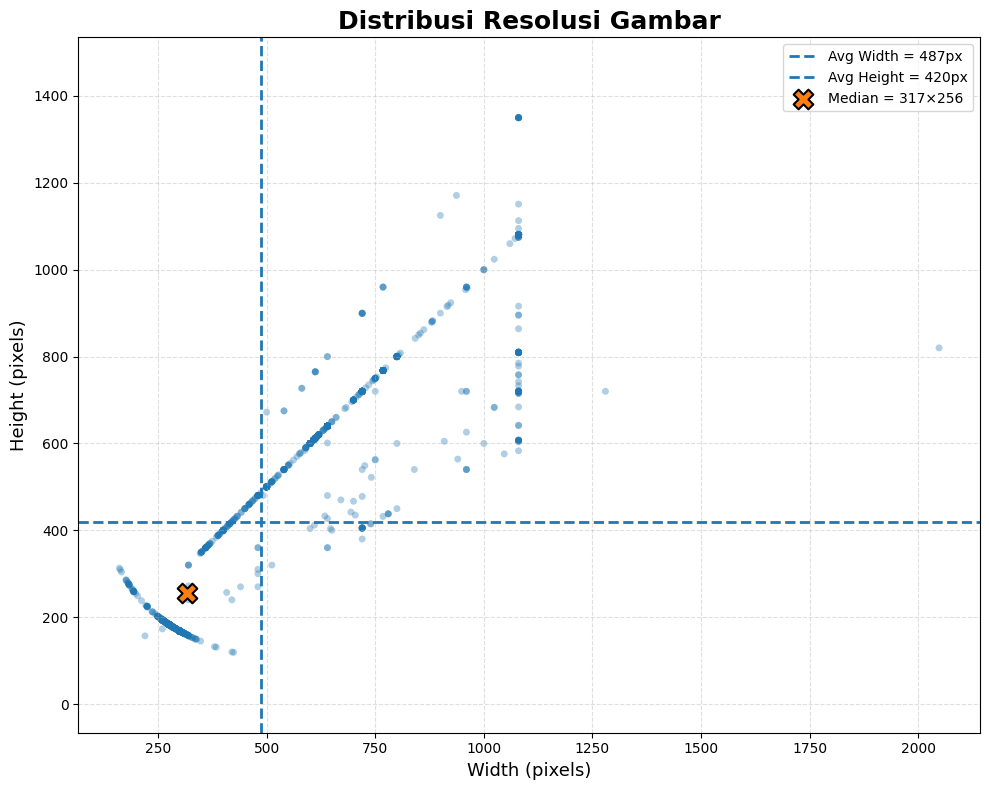

In [18]:
# Ambil ukuran gambar
widths, heights = [], []

for path in file_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

# Statistik dasar
print(f"Jumlah gambar      : {len(widths)}")
print(f"Lebar  (min-max)   : {widths.min()} - {widths.max()} px")
print(f"Tinggi (min-max)   : {heights.min()} - {heights.max()} px")
print(f"Resolusi median    : {int(np.median(widths))} x {int(np.median(heights))} px")
print(f"Resolusi rata-rata : {int(widths.mean())} x {int(heights.mean())} px")

# Visualisasi
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(
    widths,
    heights,
    alpha=0.35,
    s=25,
    edgecolors='none'
)

# Garis rata-rata
plt.axvline(widths.mean(), linestyle='--', linewidth=2,
            label=f'Avg Width = {widths.mean():.0f}px')
plt.axhline(heights.mean(), linestyle='--', linewidth=2,
            label=f'Avg Height = {heights.mean():.0f}px')

# Titik median
plt.scatter(
    np.median(widths),
    np.median(heights),
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.5,
    label=f'Median = {int(np.median(widths))}×{int(np.median(heights))}'
)

# Label dan judul
plt.title('Distribusi Resolusi Gambar', fontsize=18, fontweight='bold')
plt.xlabel('Width (pixels)', fontsize=13)
plt.ylabel('Height (pixels)', fontsize=13)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Aspect ratio agar proporsional
plt.axis('equal')

# Legend
plt.legend(frameon=True)

# Layout rapih
plt.tight_layout()

plt.show()

## Image Brightness Analysis

/tmp/ipykernel_23/4035679280.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(brightness_values, labels=class_names)


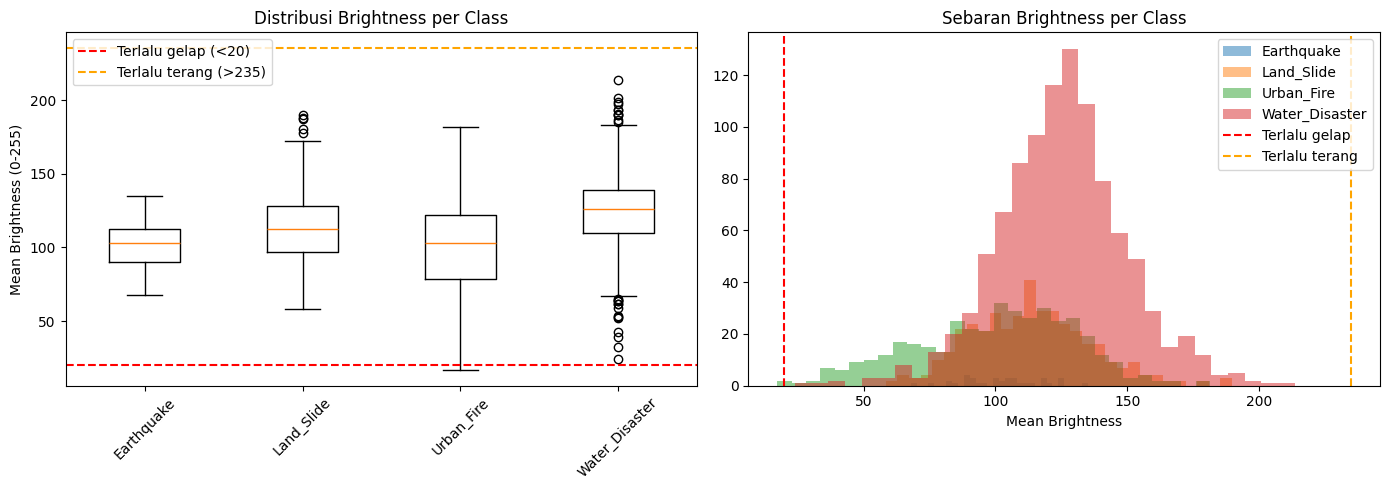

In [19]:
# Kumpulkan brightness per class
brightness_per_class = {}

for path, label in zip(file_paths, labels):
    img = np.array(Image.open(path).convert('L'))
    brightness = img.mean()
    
    class_name = label_map[label]  # ← convert integer ke nama
    if class_name not in brightness_per_class:
        brightness_per_class[class_name] = []
    brightness_per_class[class_name].append((brightness, path))

# Pisahkan value dan path
class_names = list(brightness_per_class.keys())
brightness_values = [[b for b, _ in brightness_per_class[c]] for c in class_names]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot per class
axes[0].boxplot(brightness_values, labels=class_names)
axes[0].axhline(y=20,  color='red',    linestyle='--', label='Terlalu gelap (<20)')
axes[0].axhline(y=235, color='orange', linestyle='--', label='Terlalu terang (>235)')
axes[0].set_title('Distribusi Brightness per Class')
axes[0].set_ylabel('Mean Brightness (0-255)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2. Histogram overlay per class
for cls, values in zip(class_names, brightness_values):
    axes[1].hist([v for v in values], bins=30, alpha=0.5, label=cls)
axes[1].axvline(20,  color='red',    linestyle='--', label='Terlalu gelap')
axes[1].axvline(235, color='orange', linestyle='--', label='Terlalu terang')
axes[1].set_title('Sebaran Brightness per Class')
axes[1].set_xlabel('Mean Brightness')
axes[1].legend()

plt.tight_layout()
plt.show()

## Image / Color Channel Analysis

In [20]:
# Cek channel semua gambar
channel_info = []
for path, label in zip(file_paths, labels):
    img = Image.open(path)
    mode = img.mode  # 'RGB', 'RGBA', 'L', dll
    channel_info.append((mode, label_map[label], path))

# Ringkasan
modes = [m for m, _, _ in channel_info]
print("=== Distribusi Channel ===")
for mode, count in Counter(modes).items():
    print(f"  {mode}: {count} gambar")

# Tampilkan file yang bukan RGB
print("\n=== File Bukan RGB ===")
for mode, class_name, path in channel_info:
    if mode != 'RGB':
        print(f"  [{mode}] {class_name} → {path}")

=== Distribusi Channel ===
  RGB: 1845 gambar
  L: 1 gambar

=== File Bukan RGB ===
  [L] Land_Slide → /kaggle/input/datasets/tungstor1/disaster-image-dataset/Disaster Image Dataset/Land_Slide/04_01_0264.png


## Mean Image per Classes Analysis

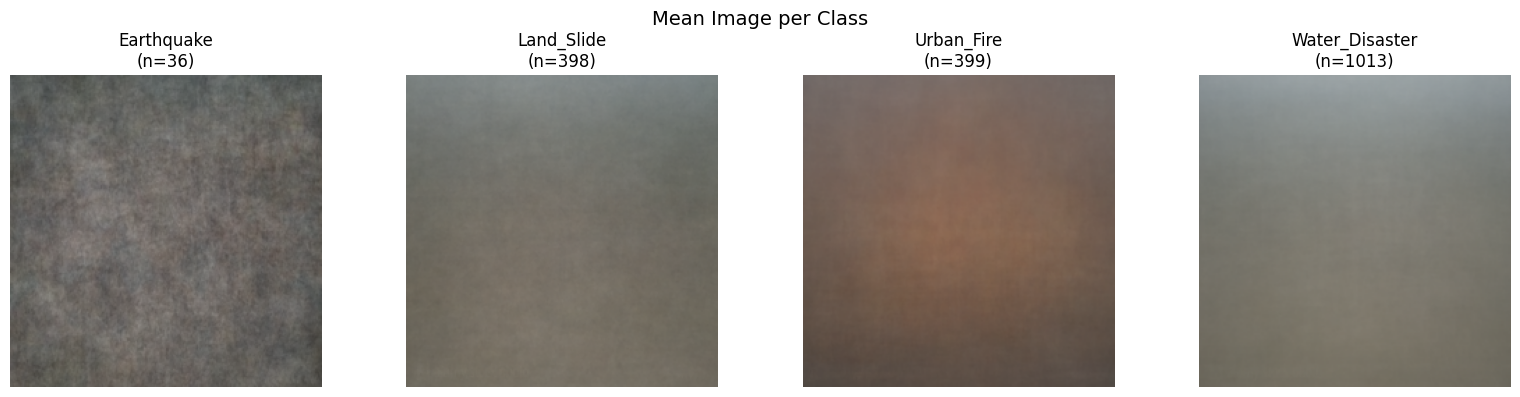

In [21]:
label_map = {0: 'Earthquake', 1: 'Land_Slide', 2: 'Urban_Fire', 3: 'Water_Disaster'}

# Kelompokkan path per class
paths_per_class = {name: [] for name in label_map.values()}
for path, label in zip(file_paths, labels):
    paths_per_class[label_map[label]].append(path)

# Plot mean image per class
fig, axes = plt.subplots(1, len(label_map), figsize=(16, 4))

for ax, (class_name, class_paths) in zip(axes, paths_per_class.items()):
    mean_img = np.mean(
        [np.array(Image.open(p).convert('RGB').resize((224, 224))) for p in class_paths],  # ← tambah .convert('RGB')
        axis=0
    )
    ax.imshow(mean_img.astype(np.uint8))
    ax.set_title(f'{class_name}\n(n={len(class_paths)})')
    ax.axis('off')

plt.suptitle('Mean Image per Class', fontsize=14)
plt.tight_layout()
plt.show()

## Class Distribution Analysis

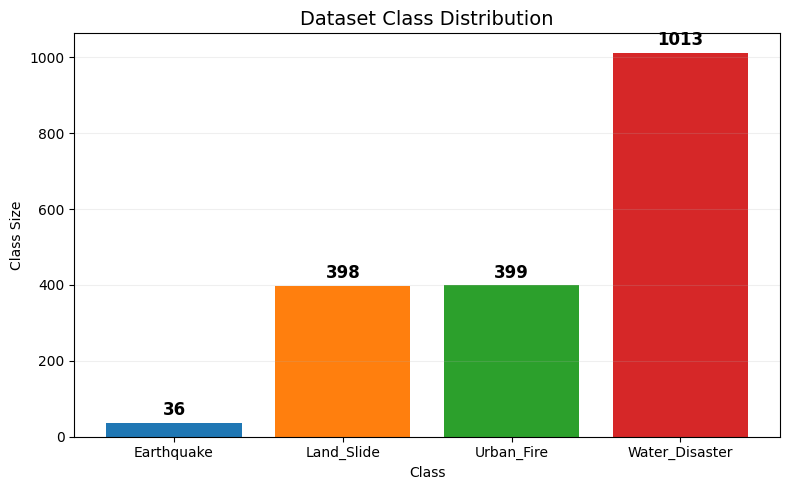

In [22]:
# Hitung jumlah tiap kelas
counter = Counter(labels)
class_counts = [counter[i] for i in range(4)]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, class_counts, color=sns.color_palette("tab10"))

# Tambah angka di atas tiap bar
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")
    plt.grid(axis="y", linestyle="-", alpha=0.2)

plt.title("Dataset Class Distribution", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Class Size")
plt.tight_layout()
plt.show()

## Sample per Classes

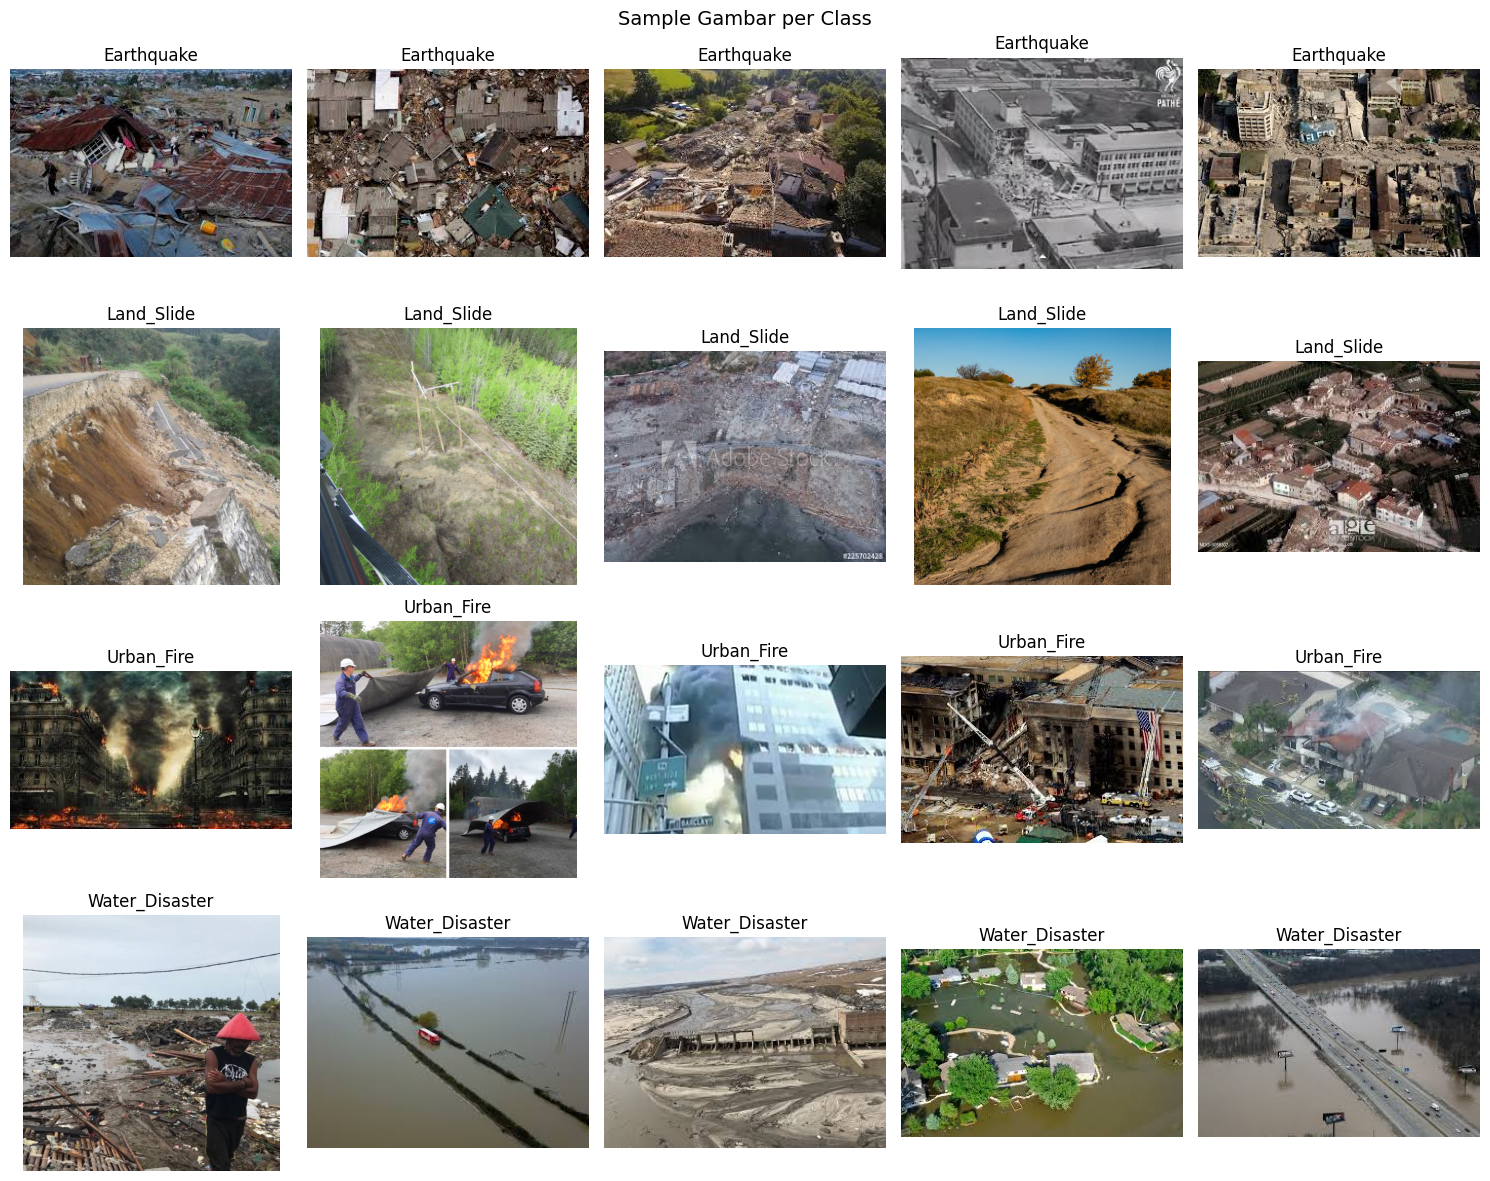

In [23]:
fig, axes = plt.subplots(len(paths_per_class), 5, figsize=(15, 3*len(paths_per_class)))

for i, (class_name, class_paths) in enumerate(paths_per_class.items()):
    samples = random.sample(class_paths, 5)
    for j, path in enumerate(samples):
        axes[i][j].imshow(Image.open(path).convert('RGB'))
        axes[i][j].set_title(class_name)
        axes[i][j].axis('off')

plt.suptitle('Sample Gambar per Class', fontsize=14)
plt.tight_layout()
plt.show()

## RGB Distribution per Classes

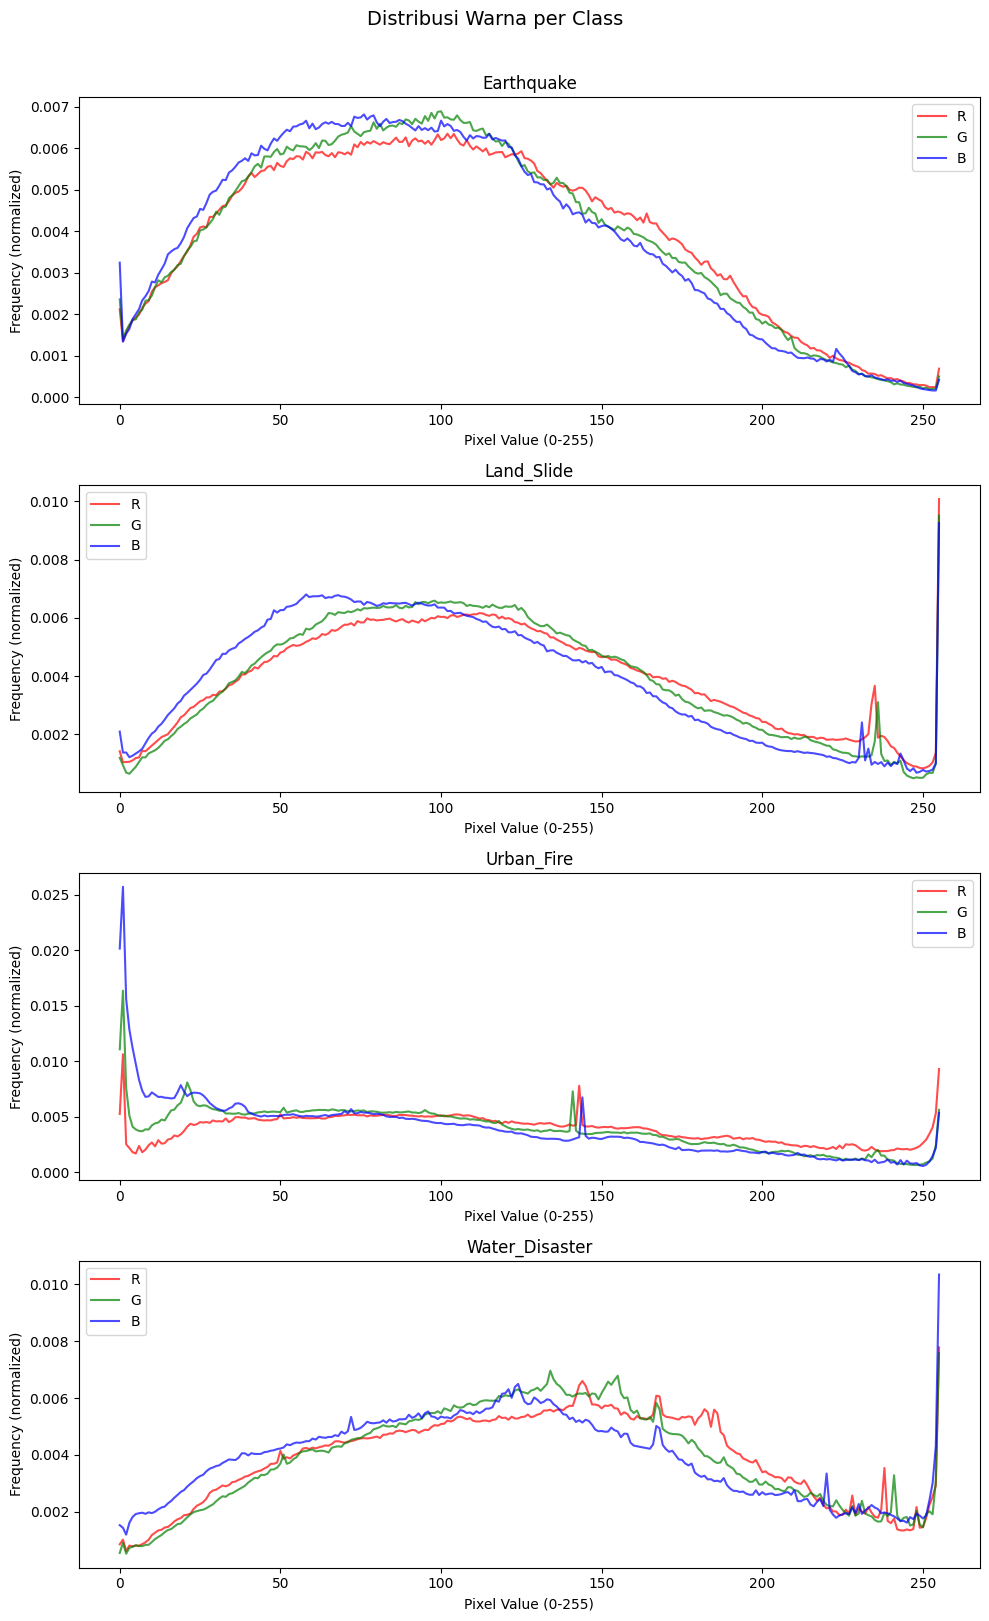

In [24]:
colors = ['red', 'green', 'blue']
channels = ['R', 'G', 'B']

fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for class_id, class_name in label_map.items():
    ax = axes[class_id]
    
    class_paths = [p for p, l in zip(file_paths, labels) if l == class_id][:100]
    
    hist_r = np.zeros(256)
    hist_g = np.zeros(256)
    hist_b = np.zeros(256)
    
    for path in class_paths:
        img = np.array(Image.open(path).convert('RGB').resize((224, 224)))
        hist_r += np.bincount(img[:,:,0].flatten(), minlength=256)
        hist_g += np.bincount(img[:,:,1].flatten(), minlength=256)
        hist_b += np.bincount(img[:,:,2].flatten(), minlength=256)
    
    hist_r /= hist_r.sum()
    hist_g /= hist_g.sum()
    hist_b /= hist_b.sum()
    
    ax.plot(hist_r, color='red',   label='R', alpha=0.7)
    ax.plot(hist_g, color='green', label='G', alpha=0.7)
    ax.plot(hist_b, color='blue',  label='B', alpha=0.7)
    ax.set_title(class_name)
    ax.set_xlabel('Pixel Value (0-255)')
    ax.set_ylabel('Frequency (normalized)')
    ax.legend()  # ← tambah ini

plt.suptitle('Distribusi Warna per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 📊 Exploratory Data Analysis — Disaster Image Dataset

---

## 1. Dataset Class Distribution

Dari bar chart distribusi kelas, dataset ini memiliki **total 1.846 gambar** yang terbagi ke dalam 4 kelas:

| Kelas | Jumlah | Proporsi |
|---|---|---|
| **Earthquake** | 36 | ~1.95% |
| **Land_Slide** | 398 | ~21.6% |
| **Urban_Fire** | 399 | ~21.6% |
| **Water_Disaster** | 1013 | ~54.9% |

Dataset ini mengalami **class imbalance yang sangat ekstrem**, khususnya pada kelas `Earthquake` yang hanya memiliki 36 sampel — sekitar **28× lebih sedikit** dibanding `Water_Disaster`. Kondisi ini berpotensi menyebabkan model bias ke kelas mayoritas jika tidak ditangani. Kelas `Land_Slide` dan `Urban_Fire` relatif seimbang satu sama lain (~398–399 sampel), sementara `Water_Disaster` mendominasi lebih dari separuh dataset.

> ⚠️ **Implikasi:** Perlu penanganan class imbalance, misalnya dengan **oversampling** (augmentasi data pada kelas minor), **undersampling**, penggunaan **class weights**, atau kombinasi ketiganya — terutama untuk kelas `Earthquake`.

**Yang akan dilakukan adalah eksperimen dengan oversampling dan dengan class weights (kedua metode menggunakan augmentasi untuk memastikan model cukup robust dengan data nyata)**

---

## 2. Distribusi Resolusi Gambar

Dari scatter plot resolusi, terlihat persebaran ukuran gambar yang sangat beragam:

| Statistik | Lebar (Width) | Tinggi (Height) |
|---|---|---|
| **Minimum** | 161 px | 119 px |
| **Maksimum** | 2048 px | 1350 px |
| **Median** | 317 px | 256 px |
| **Rata-rata** | 487 px | 420 px |

Karena **mean > median** pada kedua dimensi, distribusi resolusi bersifat **right-skewed (positively skewed)** — artinya sebagian besar gambar berukuran kecil (berkumpul di sekitar median 317×256 px), namun terdapat sejumlah gambar beresolusi tinggi yang menarik rata-rata ke atas. Pola diagonal pada scatter plot juga mengindikasikan bahwa banyak gambar mempertahankan **aspect ratio yang konsisten** (proporsi lebar:tinggi tetap).

Terdapat beberapa outlier ekstrem, seperti satu gambar dengan lebar ~2048 px namun tinggi hanya ~820 px (rasio panoramik), dan beberapa gambar dengan tinggi mendekati 1350 px.

> ⚠️ **Implikasi:** Semua gambar perlu di-resize ke ukuran seragam sebelum masuk ke pipeline model (yang akan digunakan 224×224). Perbedaan resolusi yang besar antar gambar dapat mempengaruhi kualitas fitur yang diekstrak jika tidak dinormalisasi terlebih dahulu.

---

## 3. Distribusi Brightness per Class

### 3.1 Boxplot — Persebaran Brightness

| Kelas | Median ~ | IQR | Outlier | Catatan |
|---|---|---|---|---|
| **Earthquake** | ~105 | Sempit | Minimal | Paling konsisten, sebaran sangat terkontrol |
| **Land_Slide** | ~110 | Sedang | Beberapa ke atas | Outlier cerah diduga gambar berlatar langit |
| **Urban_Fire** | ~105 | **Sangat lebar** | Beberapa | Variasi sangat tinggi: gambar api vs. latar hangus |
| **Water_Disaster** | ~128 | Lebar | **Banyak, ekstrem** | Data paling beragam: siang/malam, air jernih/keruh |

- **Earthquake** memiliki boxplot paling sempit karena jumlah data sangat sedikit (n=36), sehingga variasi naturalnya memang terbatas.
- **Urban_Fire** memiliki IQR yang sangat besar mencerminkan dua kondisi dominan dalam dataset: gambar saat kebakaran berlangsung (pixel cerah, kemerahan) dan gambar pasca-kebakaran (latar hangus, pixel gelap).
- **Water_Disaster** memiliki paling banyak outlier, baik di ujung gelap (gambar malam/banjir keruh) maupun terang (gambar siang hari/permukaan air memantulkan cahaya). Beberapa outlier ekstrem bisa merupakan gambar yang corrupt atau under/overexposed.
- Semua kelas masih berada dalam batas threshold yang wajar (**brightness > 20** dan **< 235**), artinya tidak ada kelas yang secara keseluruhan terlalu gelap atau terlalu terang untuk diproses.

### 3.2 Histogram — Sebaran Brightness per Class

Dari histogram tumpang-tindih:
- **Water_Disaster** mendominasi secara visual karena jumlah datanya terbesar (n=1013), dengan distribusi berbentuk **bell-curve lebar** yang berpusat di sekitar brightness 120–140.
- **Earthquake** hampir tidak terlihat di histogram karena datanya sangat sedikit (n=36), menunjukkan betapa ekstremnya ketidakseimbangan kelas.
- **Land_Slide** dan **Urban_Fire** memiliki puncak di sekitar brightness 80–120, cenderung **lebih gelap** dibanding `Water_Disaster`, kemungkinan karena kondisi pemotretan (tanah longsor di lingkungan gersang, atau kebakaran di malam hari).

> ⚠️ **Implikasi:** Normalisasi brightness atau histogram equalization bisa menjadi teknik augmentasi yang relevan, terutama untuk menyeimbangkan perbedaan kondisi pencahayaan antar kelas.

---

## 4. Distribusi Channel Gambar

```
=== Distribusi Channel ===
  RGB : 1845 gambar
  L   : 1 gambar  (Grayscale)

=== File Bukan RGB ===
  [L] Land_Slide → .../Land_Slide/04_01_0264.png
```

Dari total 1.846 gambar, **1.845 gambar berformat RGB (3 channel)** dan **1 gambar berformat Grayscale/Luminance (1 channel)** yang berasal dari kelas `Land_Slide`. Meskipun hanya satu, gambar ini perlu ditangani secara eksplisit agar tidak menyebabkan error saat batching karena ketidaksesuaian dimensi tensor.

**Solusi yang direkomendasikan:**

```python
# Gunakan parameter channels=3 agar:
# - Grayscale (L) otomatis diexpand menjadi 3 channel
# - RGBA otomatis dibuang alpha channel-nya
tf.io.decode_image(img, channels=3, expand_animations=False)
```

Ini cukup diterapkan pada fungsi `load_image` atau `load_image_aug` di pipeline preprocessing agar semua gambar secara konsisten memiliki shape `(H, W, 3)`.

---

## 5. Mean Image per Class

Mean image adalah rata-rata piksel dari seluruh gambar dalam satu kelas, merepresentasikan "warna khas" dominan dari tiap kelas secara keseluruhan.

| Kelas | Warna Dominan | Interpretasi |
|---|---|---|
| **Earthquake** (n=36) | Abu-abu gelap berbercak | Mencerminkan latar reruntuhan, tanah retak, dan permukiman rusak. Tekstur kasar terlihat akibat variasi gambar yang beragam meski jumlah sedikit. |
| **Land_Slide** (n=398) | Coklat keabu-abuan | Mencerminkan warna tanah dan material longsor. Gradasi halus dari atas ke bawah menunjukkan banyak gambar dengan komposisi langit di atas dan tanah di bawah. |
| **Urban_Fire** (n=399) | Coklat kemerahan, gelap di pinggir | Warna kemerahan di tengah mencerminkan rata-rata gambar api/kebakaran, sedangkan warna gelap di area pinggir mencerminkan latar hangus dari gambar pasca-kebakaran. |
| **Water_Disaster** (n=1013) | Abu-abu terang homogen | Karena memiliki data terbanyak, rata-ratanya lebih "halus" dan homogen. Warna abu-abu terang mencerminkan campuran air, langit, dan banjir dari berbagai kondisi. |

> 💡 **Insight:** Meskipun mean image per kelas menunjukkan perbedaan warna yang cukup jelas (terutama `Urban_Fire` yang kemerahan vs. `Water_Disaster` yang abu-abu terang), perbedaan ini cukup subtle untuk membuat model CNN harus mengandalkan fitur tekstur dan lokal — bukan hanya warna global — untuk membedakan antar kelas. Ini juga mengindikasikan bahwa **color augmentation** (brightness, contrast, saturation jitter) dapat membantu generalisasi model.

---

## 6. Distribusi Warna per Class (RGB Histogram)

### 6.1 Earthquake
Distribusi RGB membentuk **kurva bell yang relatif simetris**, berpusat di sekitar pixel value 100–130. Ketiga channel (R, G, B) cukup berdekatan satu sama lain, menandakan gambar didominasi **warna netral/abu-abu** (earthy tones). Channel **Blue sedikit lebih tinggi** di nilai gelap, dan **Red sedikit lebih tinggi** di nilai terang — konsisten dengan warna coklat keabu-abuan yang terlihat di mean image. Tidak ada spike ekstrem di ujung distribusi (0 atau 255).

### 6.2 Land_Slide
Distribusi mirip bell namun dengan **channel Blue memiliki spike tajam di nilai 255** — mengindikasikan adanya subset gambar dengan langit biru cerah sebagai latar belakang (outlier terang pada boxplot). Channel **Red dan Green** cenderung lebih tinggi frekuensinya di rentang tengah (80–150), konsisten dengan warna tanah/lumpur. Secara umum distribusinya **cukup sehat dan terdistribusi merata**, tanpa konsentrasi ekstrem di salah satu ujung.

### 6.3 Urban_Fire
Distribusi RGB paling **bimodal dan unik** di antara semua kelas:
- **Spike tajam di pixel value 0–10**: Mencerminkan banyaknya piksel hitam/sangat gelap dari gambar pasca-kebakaran (latar hangus, area terbakar).
- **Channel Blue paling tinggi** di sisi gelap, menandakan area gelap mendominasi tone dingin/gelap.
- **Spike di pixel value ~255**: Terutama pada channel **Red**, mencerminkan piksel api yang sangat terang dan jenuh merah.
- **Channel Red secara konsisten lebih tinggi** di rentang tengah–terang, konsisten dengan karakteristik gambar kebakaran.

Distribusi ini mengonfirmasi bahwa dataset `Urban_Fire` mengandung **dua kondisi yang sangat berbeda** secara visual: gambar aktif kebakaran (dominan terang dan merah) dan gambar pasca-kebakaran (dominan gelap dan hitam).

### 6.4 Water_Disaster
Distribusi RGB **paling gradual dan merata** dibandingkan kelas lain, mencerminkan keberagaman data yang tinggi (n=1013). Beberapa karakteristik:
- Frekuensi **meningkat secara landai** dari nilai gelap ke terang, dengan puncak di sekitar 100–150.
- **Spike di ujung 255** terutama pada channel **Blue** — mengindikasikan gambar dengan permukaan air memantulkan langit terang atau foto yang diambil siang hari.
- Channel **Red** cenderung sedikit lebih tinggi di rentang terang (150–220) dibanding G dan B, konsisten dengan gambar air yang keruh atau kondisi sore hari.
- Tidak ada spike ekstrem di sisi gelap (tidak seperti Urban_Fire), menunjukkan mayoritas gambar banjir diambil dalam kondisi pencahayaan yang cukup.

---

## 🔑 Ringkasan Temuan & Rekomendasi

| Aspek | Temuan | Rekomendasi |
|---|---|---|
| **Class Imbalance** | Earthquake sangat minor (n=36 vs 1013) | Augmentasi + class weights |
| **Resolusi** | Sangat bervariasi (161–2048 px width) | Resize seragam ke `224×224` atau 256×256 |
| **Channel** | 1 gambar grayscale di Land_Slide | `decode_image(..., channels=3)` |
| **Brightness** | Water_Disaster paling bervariasi, Urban_Fire bimodal | Brightness/contrast augmentation |
| **Warna** | Urban_Fire bimodal (api vs. hangus); Water_Disaster paling heterogen | Color jitter augmentation |
| **Mean Image** | Urban_Fire paling distinktif (kemerahan) | Model berpotensi bisa memanfaatkan fitur warna |

# Data Spliting

## Spliting Setup 

In [25]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=2/3,
    stratify=temp_labels,
    random_state=SEED
)

## Function for Spliting

In [26]:
# Function for load image and make tensor dataset
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape((None, None, 3))
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.cast(img, tf.float32) / 255.0
    
    return img, label

def load_image_aug(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape((None, None, 3))
    img = tf.image.resize_with_pad(img, 224, 224)
    
    # Augmentasi
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=50.0)
    img = tf.clip_by_value(img, 0.0, 255.0) # agar hasil random_brightness tetap dirange 0-255 sebelum di normalisasi
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.cast(img, tf.float32) / 255.0
    
    return img, label 

def make_ds(paths, labels, shuffle=False, oversampling=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if oversampling:
        counter = Counter(labels)
        max_label = max(counter.values())
        ori_paths, ori_labels = list(paths), list(labels)
        samp_paths, samp_labels = [], []

        for i in range(len(label_map)):
            class_paths = [p for p, l in zip(paths, labels) if l == i]
            samp_size = max_label - len(class_paths)
            if samp_size > 0:
                samp = random.choices(class_paths, k=samp_size)
                samp_paths.extend(samp)
                samp_labels.extend([i] * samp_size)

        ori = tf.data.Dataset.from_tensor_slices((ori_paths, ori_labels))
        ori = ori.map(load_image, num_parallel_calls=AUTOTUNE, deterministic=True)

        aug = tf.data.Dataset.from_tensor_slices((samp_paths, samp_labels))
        aug = aug.map(load_image_aug, num_parallel_calls=AUTOTUNE, deterministic=True)

        ds = ori.concatenate(aug)
        ds = ds.shuffle(len(ori_paths) + len(samp_paths), seed=SEED)
    elif shuffle:
        ds = ds.shuffle(len(paths), seed = SEED)
        ds = ds.map(load_image_aug, num_parallel_calls=AUTOTUNE, deterministic=True)
    else:
        ds = ds.map(load_image, num_parallel_calls=AUTOTUNE, deterministic=True)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

## Spliting Data

In [27]:
oversamp_ds = make_ds(train_paths, train_labels, oversampling=True)
train_ds = make_ds(train_paths, train_labels, shuffle = True)
test_ds = make_ds(test_paths, test_labels)
val_ds = make_ds(val_paths, val_labels)

## Spliting Distribution

In [28]:
print("="*3, "Ukuran Data Train | Val | Test", "="*3)
print("-"*38)

print("Data size :", len(train_paths) + len(val_paths) + len(test_paths))
print("Train size:", len(train_paths))
print("Val size  :", len(val_paths))
print("Test size :", len(test_paths))
print("-"*38)

=== Ukuran Data Train | Val | Test ===
--------------------------------------
Data size : 1846
Train size: 1292
Val size  : 184
Test size : 370
--------------------------------------


# Model Train Setup

In [29]:
@tf.keras.utils.register_keras_serializable()
def macro_f1(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, tf.int64)
    
    num_classes = 4
    f1_scores = []
    
    for i in range(num_classes):
        tp = tf.reduce_sum(tf.cast((y_pred == i) & (y_true == i), tf.float32))
        fp = tf.reduce_sum(tf.cast((y_pred == i) & (y_true != i), tf.float32))
        fn = tf.reduce_sum(tf.cast((y_pred != i) & (y_true == i), tf.float32))
        
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        f1_scores.append(f1)
    
    return tf.reduce_mean(tf.stack(f1_scores))

macro_f1.__name__ = 'macro_f1'  # supaya Keras kenali sebagai 'val_macro_f1'

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        # mode='max', # karena default keras kebanyakan minimize / keseluruhan? kalo pakai monitor = 'val_macro_f1'
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        # mode='max',
        verbose=1
    )
]

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels 
)
class_weights = dict(enumerate(weights)) # only for model without oversampling

# Model without Oversampling

In [31]:
model_wo_oversamp = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

model_wo_oversamp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_wo_oversamp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_wo_oversamp = model_wo_oversamp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50


I0000 00:00:1779074043.398925      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.3861 - loss: 1.6266 - val_accuracy: 0.3967 - val_loss: 1.1595 - learning_rate: 0.0010
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.3670 - loss: 1.1639 - val_accuracy: 0.2880 - val_loss: 1.1588 - learning_rate: 0.0010
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.3222 - loss: 1.2291 - val_accuracy: 0.6793 - val_loss: 0.9097 - learning_rate: 0.0010
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5213 - loss: 1.1073 - val_accuracy: 0.6685 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5043 - loss: 1.0537 - val_accuracy: 0.6467 - val_loss: 0.8300 - learning_rate: 0.0010
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5062 - loss: 1.0658 - val_accuracy: 0.5815 - val_loss: 0.9220 - learning_rate: 0.0010
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5319 - loss: 0.9523 - val_accuracy: 0.46

# Model With Oversampling

In [33]:
model_w_oversamp = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

model_w_oversamp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_w_oversamp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_w_oversamp = model_w_oversamp.fit(
    oversamp_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.3805 - loss: 1.5194 - val_accuracy: 0.5435 - val_loss: 1.0379 - learning_rate: 0.0010
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6423 - loss: 0.8798 - val_accuracy: 0.6467 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7301 - loss: 0.6589 - val_accuracy: 0.6359 - val_loss: 0.8563 - learning_rate: 0.0010
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8203 - loss: 0.4661 - val_accuracy: 0.6793 - val_loss: 0.8510 - learning_rate: 0.0010
Epoch 5/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8716 - loss: 0.3284
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8718 - loss: 0.3284 - val_accuracy: 0.6630 - val_loss: 1.1369 - learning_rate: 0.0010
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9179 - loss: 0.2143 - val_acc

# Evaluation Model From Scratch

## Plot History (loss)

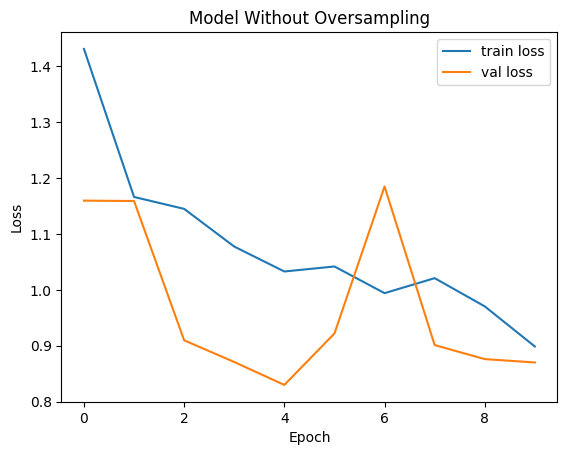

In [35]:
plt.plot(history_wo_oversamp.history['loss'], label='train loss')
plt.plot(history_wo_oversamp.history['val_loss'], label='val loss')

plt.title('Model Without Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

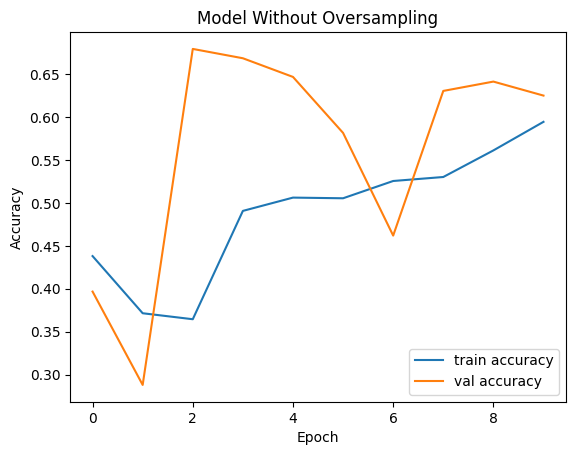

In [36]:
plt.plot(history_wo_oversamp.history['accuracy'], label='train accuracy')
plt.plot(history_wo_oversamp.history['val_accuracy'], label='val accuracy')

plt.title('Model Without Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

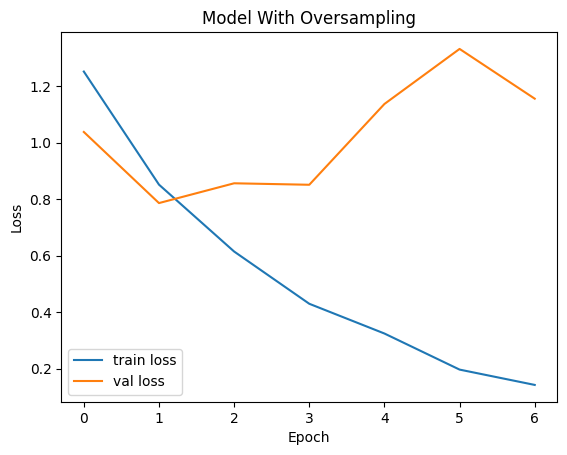

In [37]:
plt.plot(history_w_oversamp.history['loss'], label='train loss')
plt.plot(history_w_oversamp.history['val_loss'], label='val loss')

plt.title('Model With Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

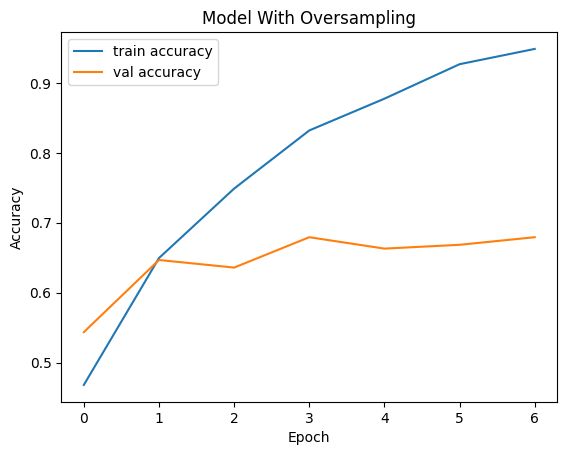

In [38]:
plt.plot(history_w_oversamp.history['accuracy'], label='train accuracy')
plt.plot(history_w_oversamp.history['val_accuracy'], label='val accuracy')

plt.title('Model With Oversampling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Numerical Metrics

In [39]:
print("="*3, "Model Without Oversampling", "="*3)
print("="*3, "  Lastest Epoch Metrics   ", "="*3)
print("Train loss     :", round(history_wo_oversamp.history['loss'][-1], 4))
print("Val loss       :", round(history_wo_oversamp.history['val_loss'][-1], 4))
print("Train Accuracy :", round(history_wo_oversamp.history['accuracy'][-1], 4))
print("Val Accuracy   :", round(history_wo_oversamp.history['val_accuracy'][-1], 4))
print("="*34)

best_epoch_wo_oversamp = np.argmin(history_wo_oversamp.history['val_loss'])
print("="*3, "  Best Epoch Metrics      ", "="*3)
print("Epoch", best_epoch_wo_oversamp+1)
print("Train loss :", round(history_wo_oversamp.history['loss'][best_epoch_wo_oversamp], 4))
print("Val loss   :", round(history_wo_oversamp.history['val_loss'][best_epoch_wo_oversamp], 4))
print("Train Accuracy :", round(history_wo_oversamp.history['accuracy'][best_epoch_wo_oversamp], 4))
print("Val Accuracy   :", round(history_wo_oversamp.history['val_accuracy'][best_epoch_wo_oversamp], 4))
print("="*34)

=== Model Without Oversampling ===
===   Lastest Epoch Metrics    ===
Train loss     : 0.8987
Val loss       : 0.8702
Train Accuracy : 0.5944
Val Accuracy   : 0.625
===   Best Epoch Metrics       ===
Epoch 5
Train loss : 1.0328
Val loss   : 0.83
Train Accuracy : 0.5062
Val Accuracy   : 0.6467


In [40]:
print("="*3, "Model With Oversampling", "="*3)
print("="*3, " Lastest Epoch Metrics ", "="*3)
print("Train loss :", round(history_w_oversamp.history['loss'][-1], 4))
print("Val loss   :", round(history_w_oversamp.history['val_loss'][-1], 4))
print("Train Accuracy :", round(history_w_oversamp.history['accuracy'][-1], 4))
print("Val Accuracy   :", round(history_w_oversamp.history['val_accuracy'][-1], 4))
print("="*31)

best_epoch_w_oversamp = np.argmin(history_w_oversamp.history['val_loss'])
print("="*3, "  Best Epoch Metrics   ", "="*3)
print("Epoch", best_epoch_w_oversamp+1)
print("Train loss :", round(history_w_oversamp.history['loss'][best_epoch_w_oversamp], 4))
print("Val loss   :", round(history_w_oversamp.history['val_loss'][best_epoch_w_oversamp], 4))
print("Train Accuracy :", round(history_w_oversamp.history['accuracy'][best_epoch_w_oversamp], 4))
print("Val Accuracy   :", round(history_w_oversamp.history['val_accuracy'][best_epoch_w_oversamp], 4))
print("="*31)

=== Model With Oversampling ===
===  Lastest Epoch Metrics  ===
Train loss : 0.1429
Val loss   : 1.1556
Train Accuracy : 0.9489
Val Accuracy   : 0.6793
===   Best Epoch Metrics    ===
Epoch 2
Train loss : 0.8515
Val loss   : 0.7863
Train Accuracy : 0.6495
Val Accuracy   : 0.6467


## Classification Report

In [41]:
y_true = []

for _, label in test_ds:
    y_true.extend(label.numpy())

y_true = np.array(y_true)

In [42]:
y_true_val = []

for _, label in val_ds:
    y_true_val.extend(label.numpy())

y_true_val = np.array(y_true_val)

In [43]:
y_wo_oversamp_prob = model_wo_oversamp.predict(test_ds)
y_wo_oversamp_pred = np.argmax(y_wo_oversamp_prob, axis = 1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [44]:
y_w_oversamp_prob = model_w_oversamp.predict(test_ds)
y_w_oversamp_pred = np.argmax(y_w_oversamp_prob, axis = 1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [45]:
class_names = ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']

In [46]:
print("Classification Report Model Without Oversampling in train_ds")
print("="*60)
print(classification_report(y_true, y_wo_oversamp_pred, target_names=class_names))
print("="*60)

Classification Report Model Without Oversampling in train_ds
                precision    recall  f1-score   support

    Earthquake       0.17      0.29      0.21         7
    Land_Slide       0.40      0.20      0.27        80
    Urban_Fire       0.44      0.75      0.56        80
Water_Disaster       0.69      0.63      0.66       203

      accuracy                           0.55       370
     macro avg       0.43      0.47      0.42       370
  weighted avg       0.57      0.55      0.54       370



In [47]:
print("Classification Report Model With Oversampling in train_ds")
print("="*57)
print(classification_report(y_true, y_w_oversamp_pred, target_names=class_names))
print("="*57)

Classification Report Model With Oversampling in train_ds
                precision    recall  f1-score   support

    Earthquake       0.00      0.00      0.00         7
    Land_Slide       0.36      0.26      0.30        80
    Urban_Fire       0.80      0.51      0.63        80
Water_Disaster       0.65      0.82      0.72       203

      accuracy                           0.62       370
     macro avg       0.45      0.40      0.41       370
  weighted avg       0.61      0.62      0.60       370



# Keras Tuner Setup

In [48]:
def build_model(hp):
    model = models.Sequential()

    # --- BLOCK 1 ---
    # Range tetap, kontribusi parameter kecil (~900 params maks)
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filter', min_value=16, max_value=64, step=16),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ))
    model.add(layers.MaxPooling2D(2, 2))

    # --- BLOCK 2 ---
    # Range tetap, kontribusi parameter masih kecil (~18K params maks)
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filter', min_value=32, max_value=128, step=32),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(layers.MaxPooling2D(2, 2))

    # --- BLOCK 3 ---
    # ✅ DIUBAH: max 128 → 64
    # Alasan: output Flatten = 26×26×conv_3 = 676×conv_3
    # conv_3=128 → 86.528 node → Dense(128) saja sudah ~11 juta params
    model.add(layers.Conv2D(
        filters=hp.Int('conv_3_filter', min_value=32, max_value=64, step=32),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Flatten())

    # --- DENSE LAYER ---
    # ✅ DIUBAH: max 256 → 128
    # Alasan: 676 × 64 (conv_3 maks) × 128 = ~5,5 juta params ✓
    model.add(layers.Dense(
        units=hp.Int('dense_1_units', min_value=64, max_value=128, step=64),
        activation='relu'
    ))

    # --- DROPOUT ---
    # Tidak diubah
    model.add(layers.Dropout(
        rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)
    ))

    # --- OUTPUT ---
    model.add(layers.Dense(4, activation='softmax'))

    # --- COMPILATION ---
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [49]:
kt_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=False
    )
]

# Keras Tuner Hyperband

In [50]:
k_tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=15,
    factor=3,
    directory='k_tuner',
    project_name='disaster_image'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
k_tuner.search(
    oversamp_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=kt_callbacks,
    verbose=2
)

Trial 30 Complete [00h 01m 12s]
val_loss: 1.3689744472503662

Best val_loss So Far: 0.6264225840568542
Total elapsed time: 00h 21m 28s


# Keras Tuner Result

In [52]:
# # Ambil model terbaik
# best_hps = k_tuner.get_best_hyperparameters(num_trials=1)[0]
# best_model = k_tuner.hypermodel.build(best_hps)
# best_model.summary()

In [53]:
best_model_trainable = k_tuner.get_best_models(num_models=1)[0]
best_model_trainable.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,650,116 (21.55 MB)

 Trainable params: 5,650,116 (21.55 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
test_loss, test_acc = best_model_trainable.evaluate(test_ds)
print(f"Test Accuracy: {test_acc}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7111 - loss: 0.6408
Test Accuracy: 0.6972972750663757


In [55]:
# Menghitung jumlah trial
num_trials = len(k_tuner.oracle.trials)
print(f"Total trials yang jalan: {num_trials}")

Total trials yang jalan: 30


In [56]:
# k_tuner.results_summary()

In [57]:
best_hps = k_tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.values)

{'conv_1_filter': 32, 'conv_2_filter': 128, 'conv_3_filter': 64, 'dense_1_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'tuner/epochs': 15, 'tuner/initial_epoch': 5, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0015'}


# Train Model From Keras Tuner

In [58]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,650,116 (21.55 MB)

 Trainable params: 5,650,116 (21.55 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history = model.fit(
    oversamp_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.4297 - loss: 1.2415 - val_accuracy: 0.6304 - val_loss: 0.8657 - learning_rate: 1.0000e-04
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.6813 - loss: 0.8253 - val_accuracy: 0.7011 - val_loss: 0.7097 - learning_rate: 1.0000e-04
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7276 - loss: 0.6692 - val_accuracy: 0.6739 - val_loss: 0.7906 - learning_rate: 1.0000e-04
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7435 - loss: 0.6153 - val_accuracy: 0.6957 - val_loss: 0.7905 - learning_rate: 1.0000e-04
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8174 - loss: 0.4747
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8173 - loss: 0.4749 - val_accuracy: 0.6902 - val_loss: 0.7369 - learning_rate: 1.0000e-04
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8387

# Evaluation Model From Keras Tuner

## Plot History

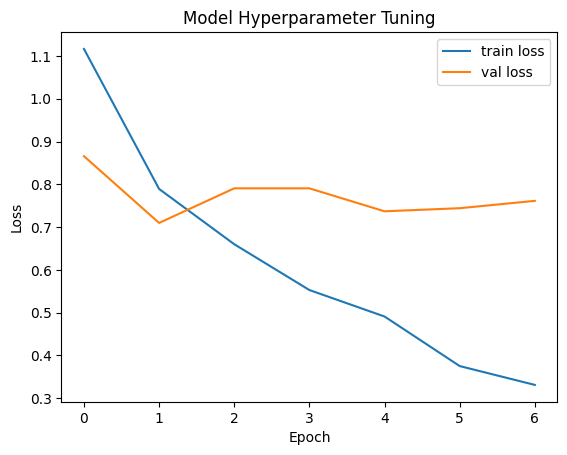

In [60]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.title('Model Hyperparameter Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

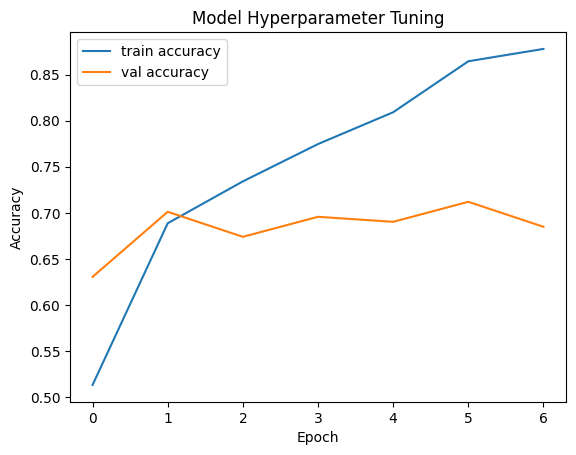

In [61]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.title('Model Hyperparameter Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Numerical Metrics

In [62]:
print("="*3, "Model Hyperparameter Tuning", "="*3)
print("="*3, "   Lastest Epoch Metrics   ", "="*3)
print("Train loss :", round(history.history['loss'][-1], 4))
print("Val loss   :", round(history.history['val_loss'][-1], 4))
print("Train Accuracy :", round(history.history['accuracy'][-1], 4))
print("Val Accuracy   :", round(history.history['val_accuracy'][-1], 4))
print("="*35)

best_epoch_ = np.argmin(history.history['val_loss'])
print("="*3, "    Best Epoch Metrics     ", "="*3)
print("Epoch", best_epoch_+1)
print("Train loss :", round(history.history['loss'][best_epoch_], 4))
print("Val loss   :", round(history.history['val_loss'][best_epoch_], 4))
print("Train Accuracy :", round(history.history['accuracy'][best_epoch_], 4))
print("Val Accuracy   :", round(history.history['val_accuracy'][best_epoch_], 4))
print("="*35)

=== Model Hyperparameter Tuning ===
===    Lastest Epoch Metrics    ===
Train loss : 0.3311
Val loss   : 0.7613
Train Accuracy : 0.878
Val Accuracy   : 0.6848
===     Best Epoch Metrics      ===
Epoch 2
Train loss : 0.7891
Val loss   : 0.7097
Train Accuracy : 0.6886
Val Accuracy   : 0.7011


## Classification Report

In [63]:
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis = 1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


In [64]:
y_prob_val = model.predict(val_ds)
y_pred_val = np.argmax(y_prob_val, axis = 1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [65]:
print("Classification Report Model Hyperparameter Tuning test_ds")
print("="*57)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*57)

Classification Report Model Hyperparameter Tuning test_ds
                precision    recall  f1-score   support

    Earthquake       0.14      0.14      0.14         7
    Land_Slide       0.42      0.28      0.33        80
    Urban_Fire       0.76      0.65      0.70        80
Water_Disaster       0.68      0.82      0.74       203

      accuracy                           0.65       370
     macro avg       0.50      0.47      0.48       370
  weighted avg       0.63      0.65      0.64       370



In [66]:
print("Classification Report Model Hyperparameter Tuning val_ds")
print("="*56)
print(classification_report(y_true_val, y_pred_val, target_names=class_names))
print("="*56)

Classification Report Model Hyperparameter Tuning val_ds
                precision    recall  f1-score   support

    Earthquake       0.33      0.25      0.29         4
    Land_Slide       0.52      0.38      0.44        39
    Urban_Fire       0.83      0.72      0.77        40
Water_Disaster       0.72      0.83      0.77       101

      accuracy                           0.70       184
     macro avg       0.60      0.55      0.57       184
  weighted avg       0.69      0.70      0.69       184

